# Outline
- Use Multivariate and Univariate Techniques to identify Outliers.

- Apply Multivariate Techniques on Area,Bath(s),Bedroom(s),Kitchens, etc

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
flats = pd.read_csv('C:/Users/Wajih/Work (DataScience)/CAPSTONE PROJECTS/Real Estate Project/Zameen.com/EDA/flats.csv',index_col=0)

In [5]:
flats.info()

<class 'pandas.DataFrame'>
Index: 1743 entries, 7 to 6481
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            1743 non-null   str    
 1   Main Location                       1743 non-null   str    
 2   Type                                1743 non-null   str    
 3   Price(Cr)                           1743 non-null   float64
 4   Bath(s)                             1722 non-null   float64
 5   Area(Marla)                         1743 non-null   float64
 6   Bedroom(s)                          1703 non-null   float64
 7   Description                         1743 non-null   str    
 8   Amenities: Main Features            1613 non-null   str    
 9   Amenities: Rooms                    1545 non-null   str    
 10  Amenities: Healthcare Recreational  1268 non-null   str    
 11  Amenities: Other Facilities         1516 non-null   str    

In [4]:
flats.isnull().sum()

Type                                       0
Price(Cr)                                  0
Bath(s)                                    9
Area(Marla)                                0
Bedroom(s)                                17
Location                                   0
Description                                0
Amenities: Main Features                  42
Amenities: Rooms                          72
Amenities: Business and Communication     97
Amenities: Community Features             93
Amenities: Healthcare Recreational       192
Amenities: Other Facilities               92
IsPrimeLoc                                 0
SolarInstalled                             0
WaterBore                                  0
CornerHouse                                0
luxury_type                                0
Built in year                            119
Parking Spaces                            82
Floor                                    239
Lobby in Building                        196
Elevators 

In [5]:
flats.describe()

,Price(Cr),Bath(s),Area(Marla),Bedroom(s),luxury_type,Built in year,Parking Spaces,Floor,Lobby in Building,Elevators,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
count,730.000000,721.000000,730.000000,713.000000,730.000000,611.000000,648.000000,491.000000,534.0,513.000000,...,576.0,0.0,465.0,457.0,636.0,549.0,457.0,317.0,226.0,86.000000
mean,3.104210,2.239945,6.128767,2.099579,0.167123,1790.965630,1.945988,3.918534,1.0,2.717349,...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.988372
std,4.034678,1.139865,3.963211,1.016666,0.373342,643.891637,5.683446,4.588971,0.0,2.331851,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.833055
min,0.230000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.0,1.000000,...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
25%,0.855000,1.000000,3.200000,1.000000,0.000000,2019.000000,1.000000,1.000000,1.0,1.000000,...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
50%,1.550000,2.000000,5.100000,2.000000,0.000000,2023.000000,1.000000,3.000000,1.0,2.000000,...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.000000
75%,3.350000,3.000000,7.600000,3.000000,0.000000,2025.000000,2.000000,5.000000,1.0,4.000000,...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.000000
max,32.000000,7.000000,36.000000,11.000000,1.000000,2054.000000,100.000000,40.000000,1.0,16.000000,...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.000000


## Univariate Approach
- Z Score --> Normal Distributions
- IQR --> Non Normal Distributions

In [6]:
# Price

<Axes: ylabel='Price(Cr)'>

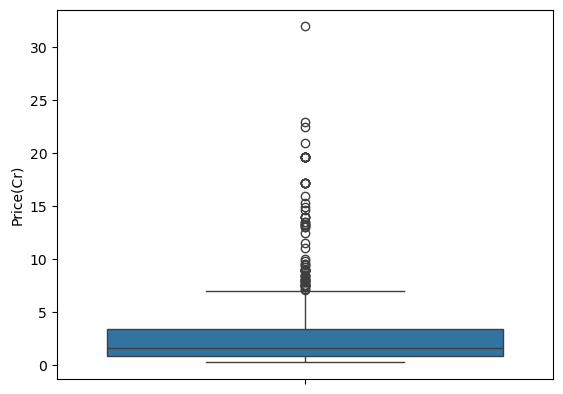

In [7]:
sns.boxplot(flats['Price(Cr)'])

In [8]:
# Investigating flats above the price of 10
flats[flats['Price(Cr)']>10]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
153,Flat,19.64,4.0,13.4,2.0,F-8,Ultra Luxury 2 Bedroom Duplex Apartment with M...,"Built in year: 2020, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
154,Flat,17.17,5.0,11.7,3.0,F-8,Purchase Directly from Centaurus Managment Thr...,"Built in year: 2023, Parking Spaces, Lobby in ...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
195,Flat,14.93,3.0,12.6,3.0,F-10,Flat Is Available on Easy Installments in Tall...,"Built in year: 2026, Parking Spaces: 4, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
254,Flat,13.25,4.0,11.8,3.0,Karakoram Diplomatic Enclave,Luxurious 3-Bedroom Fully Furnished Corner Apa...,"Lobby in Building, Central Air Conditioning, C...",NaN,"Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN
282,Flat,19.64,4.0,13.4,2.0,F-8,Ultra Luxury 2 Bedroom Duplex Apartment with M...,"Built in year: 2022, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
413,Flat,14.68,3.0,10.0,2.0,F-8,One Bedroom Apartment With Maid Room Demand: P...,"Built in year, Parking Spaces: 1, Lobby in Bui...","Bedrooms: 2, Bathrooms: 1, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
476,Flat,14.00,4.0,12.4,4.0,F-10,Best opportunity for investment. . . . Brand N...,"Built in year: 2025, Parking Spaces: 2, Lobby ...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
477,Flat,13.25,5.0,12.4,4.0,F-10,4bed Corner apartment available for Sale in Su...,"Built in year: 2025, Parking Spaces: 2, Lobby ...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
496,Flat,23.00,6.0,19.3,4.0,Constitution Avenue,4-Bedroom Apartment for Sale One Constitution ...,"Built in year: 2023, Parking Spaces: 3, Lobby ...","Bedrooms: 4, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
571,Flat,12.50,3.0,12.2,3.0,Diplomatic Enclave,3 Bedroom Modern Apartment Furnished Margalla ...,"Parking Spaces: 4, Double Glazed Windows, Cent...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


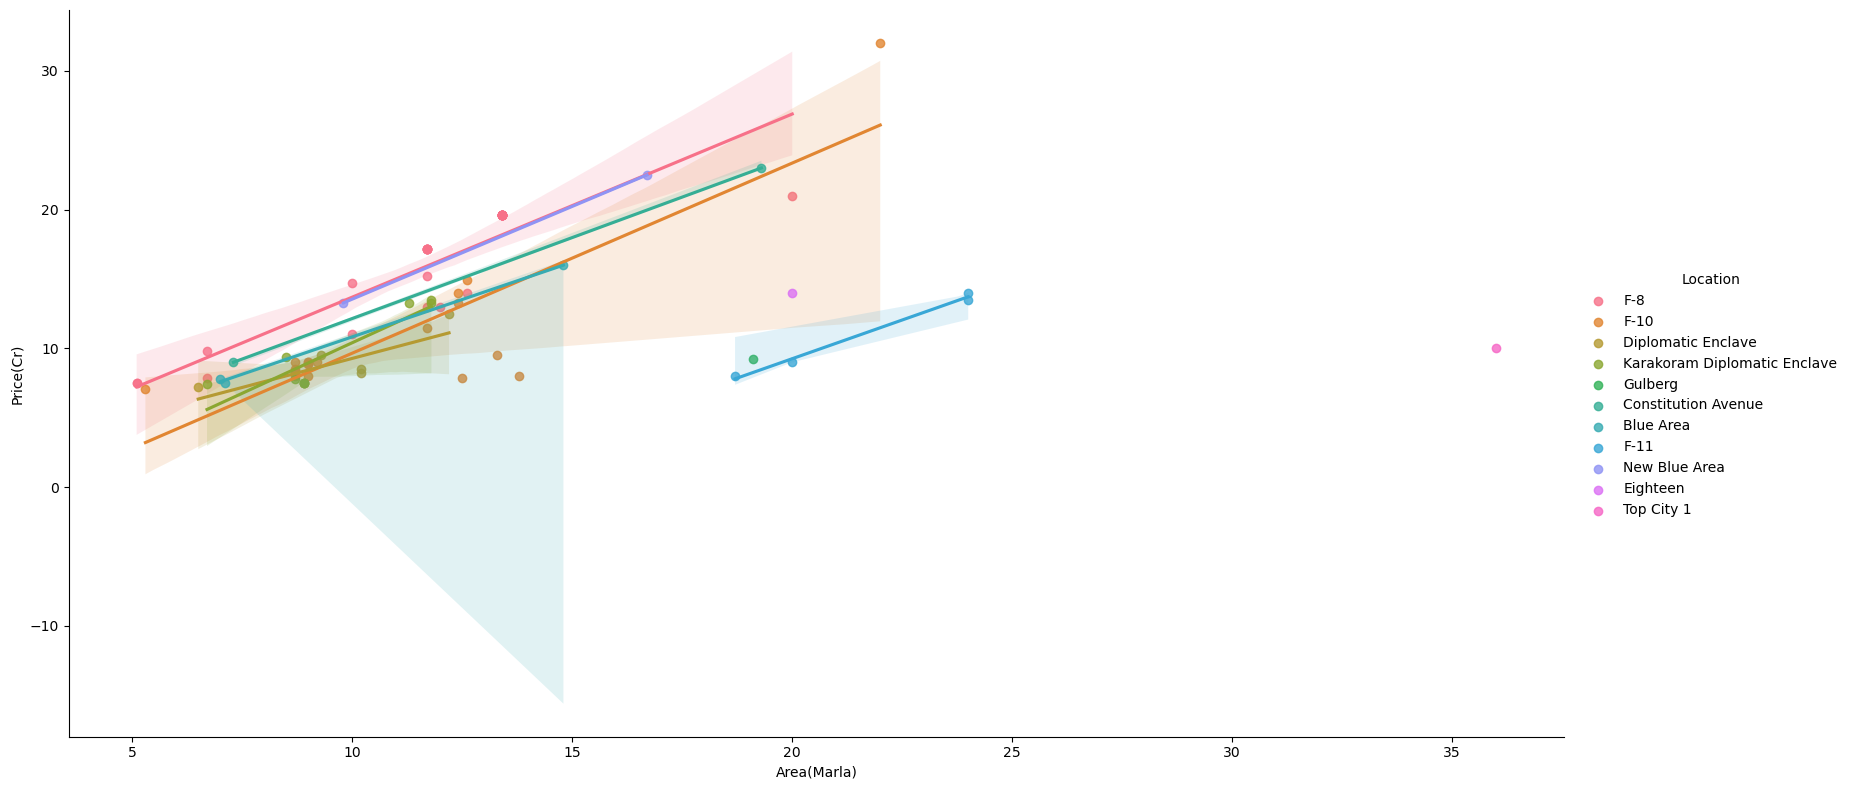

In [9]:
sns.lmplot(data=flats[flats['Price(Cr)']>7],y='Price(Cr)',x='Area(Marla)',hue='Location',height=8, 
    aspect=2)

In [10]:
flats['Description'].loc[2445]

'Spacious 5-Bedroom Penthouse for Sale in Sukh Chayn Residence, F-10 Islamabad Luxury Living at Its Finest! This beautifully designed penthouse offers: 5 Master Bedrooms with attached baths Modern Kitchen & Stylish Interiors Spacious Living & Dining Area Private Balcony with Panoramic Views All Modern Amenities (Elevators, Security, Parking, Backup Power) Prime Location in F-10 with the Best City & Margalla Hills View'

*The outliers look normal because data points are situated in Expensive Sectors*

In [11]:
# Area(Marla)

<Axes: ylabel='Area(Marla)'>

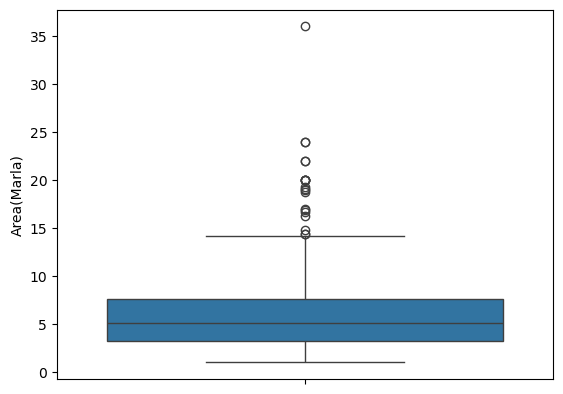

In [12]:
sns.boxplot(flats['Area(Marla)'])

In [13]:
flats[flats['Area(Marla)']>22]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
2308,Flat,14.0,3.0,24.0,3.0,F-11,This modern Apartment sits on 5500 square feet...,"Built in year: 2022, Parking Spaces: 2, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN
2420,Penthouse,13.5,4.0,24.0,3.0,F-11,Dream home in Islamabad! Welcome to Executive ...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2499,Penthouse,10.0,6.0,36.0,6.0,Top City 1,luxury brand new penthouse top view available ...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Removing data where flat's Area > 22*

In [14]:
flats = flats[~(flats['Area(Marla)']>22)]

<Axes: ylabel='Area(Marla)'>

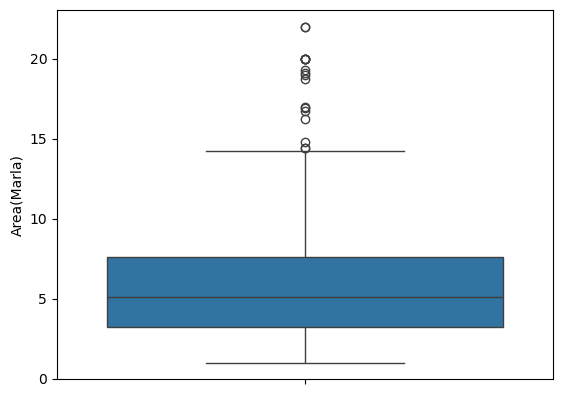

In [15]:
sns.boxplot(flats['Area(Marla)'])

**Here we have to use Bath(s) and Bedrooms(s) as main features instead of Bathrooms and Bedrooms, because there are alot of errors**

In [16]:
# Bathrooms

<Axes: xlabel='Bathrooms', ylabel='count'>

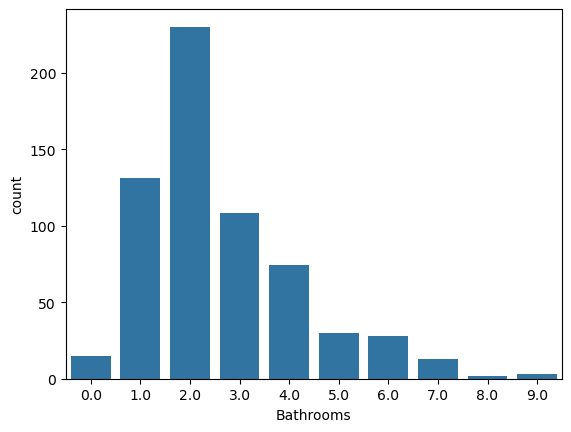

In [17]:
sns.barplot(flats['Bathrooms'].value_counts())

In [18]:
flats[flats['Bathrooms']>5][['Bathrooms','Bedrooms','Price(Cr)','Area(Marla)']]

,Bathrooms,Bedrooms,Price(Cr),Area(Marla)
97,9.0,9.0,6.0000,22.0
139,7.0,6.0,1.4000,5.3
241,6.0,5.0,1.4000,4.1
377,9.0,7.0,0.7500,2.4
396,6.0,5.0,2.0500,6.8
432,6.0,5.0,0.3800,1.6
496,7.0,4.0,23.0000,19.3
556,7.0,5.0,0.6000,2.1
644,6.0,5.0,1.1500,4.9
658,6.0,6.0,1.6500,3.3


*There are flats where the number of bathrooms and bedrooms are very high that the corresponding Area doesnot make sense*

In [19]:
# Bath(s)

In [20]:
flats['Bath(s)'].value_counts()

Bath(s)
2.0    272
1.0    209
3.0    137
4.0     70
5.0     24
6.0      4
7.0      2
Name: count, dtype: int64

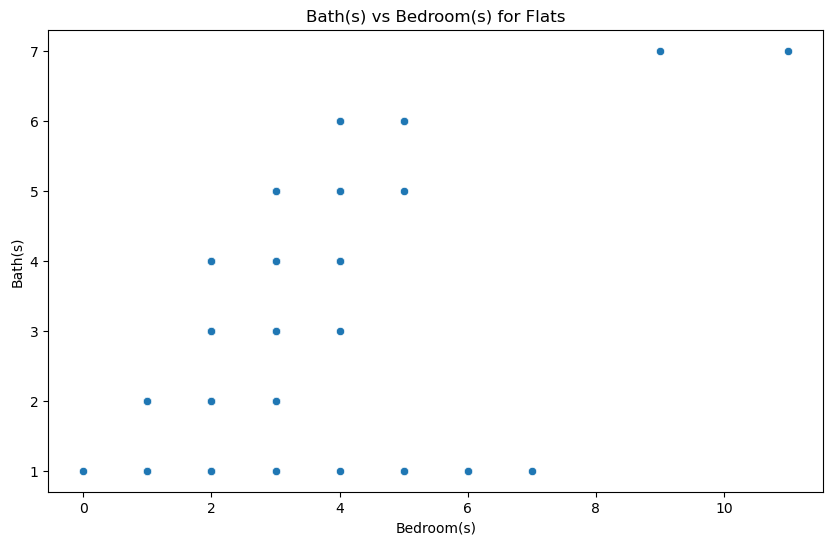

In [21]:
# Check relationship between Bath(s) and Bedroom(s)
plt.figure(figsize=(10,6))
sns.scatterplot(data=flats, x='Bedroom(s)', y='Bath(s)')
plt.title('Bath(s) vs Bedroom(s) for Flats')
plt.show()

In [22]:
# Calculating Difference between Bedrooms(s) and Bath(s)
flats['BedBath_Diff'] = flats['Bedroom(s)'] - flats['Bath(s)']

In [23]:
# Find outliers where difference is > 3 or < -3 (unusual bed/bath ratios)
outlier_rows = flats[(flats['BedBath_Diff']>3) | (flats['BedBath_Diff']<-3)]
print(f"Found {len(outlier_rows)} outliers with unusual Bed/Bath ratio")
outlier_rows[['Price(Cr)', 'Bath(s)', 'Bedroom(s)', 'Area(Marla)', 'Location']]

Found 6 outliers with unusual Bed/Bath ratio


,Price(Cr),Bath(s),Bedroom(s),Area(Marla),Location
377,0.75,1.0,7.0,2.4,Bahria Town
556,0.60,1.0,5.0,2.1,H-13
658,1.65,1.0,6.0,3.3,F-11
1799,0.36,1.0,5.0,1.6,Top City 1
1815,1.02,1.0,6.0,1.8,Islamabad Expressway
2377,1.20,7.0,11.0,1.6,DHA Defence


*For flats, typically bathrooms should be close to bedrooms. Large differnces indicate data errors.*

In [24]:
flats['Description'].loc[2377]

'Experience premium living and solid returns with this 350 sq ft luxury 3 star Marriott hotel suite located in Florence Galleria, a landmark project by Imarat Group on Main GT Road, DHA Phase 2, Islamabad. This fully serviced suite combines elegant design with international hospitality standards, making it a perfect investment property for both local and overseas buyers. Property Highlights: Size: 350 sq ft Price: Rs 11,725,000 Monthly Rent: Rs 97,000 (Guaranteed Income) Prime GT Road front location near Giga Mall Developed by Imarat Group Fully managed hotel suite hassle-free investment World-class amenities: central AC/heating, lifts, 24/7 security, power backup, concierge & room service Ideal for passive investors seeking steady rental income and long-term capital appreciation Contact now for details, payment plans, and booking limited units available!'

In [25]:
# Check a few descriptions to understand the data
for idx in outlier_rows.index[:3]:
    print(f"Index {idx}:")
    print(flats['Description'].loc[idx][:200] + "...")
    print("-"*50)

Index 377:
cube Appartments Bahria Enclave Studio Apartment for sale All dues clear Outside parking paid 10 lakh. 7th floor Rental Value 40k...
--------------------------------------------------
Index 556:
Modern Living Meets Smart Investment Discover an exceptional opportunity to own your dream home in the heart of H-13 Islamabad one of the most rapidly developing and high-demand areas near G-13, NUST,...
--------------------------------------------------
Index 658:
Al Rehman associate Offers a Prime Location Luxury 1 Bed Apartment Here are the features: . Luxury Bedrooms . Modern Bathrooms . Drawing dinning . TV Lounge . Kitchen . Big lawn . Servant Quarter . St...
--------------------------------------------------


In [26]:
# Remove outliers with unusual Bed/Bath ratio
print(f"Before removal: {flats.shape[0]} rows")
flats = flats[~((flats['BedBath_Diff']>3) | (flats['BedBath_Diff']<-3))]
print(f"After removal: {flats.shape[0]} rows")

Before removal: 727 rows
After removal: 721 rows


In [27]:
flats.drop(columns=['Bathrooms','Bedrooms'],inplace=True)

## Built in Year Analysis

In [28]:
flats['Built in year'].value_counts().sort_index()

Built in year
1.0        44
2.0         6
3.0         6
4.0         3
5.0         6
7.0         1
8.0         2
10.0        1
21.0        1
2004.0      1
2008.0      1
2009.0      2
2010.0     14
2011.0      5
2012.0      7
2013.0      2
2015.0     13
2016.0      6
2017.0      6
2018.0     21
2019.0      7
2020.0     35
2021.0     23
2022.0     42
2023.0     65
2024.0     93
2025.0    151
2026.0     17
2027.0     18
2028.0      2
2029.0      2
2054.0      1
Name: count, dtype: int64

In [29]:
# Check for year errors (unusual values)
flats[flats['Built in year'] < 1800]['Built in year'].value_counts()

Built in year
1.0     44
2.0      6
3.0      6
5.0      6
4.0      3
8.0      2
7.0      1
10.0     1
21.0     1
Name: count, dtype: int64

*Fixing year errors - setting obvious typos to correct values, and setting invalid years to NaN*

In [30]:
# Year correction mapping
year_errors = {
    20223: 2023,
    20242: 2024,
    225: 2025,
    2250: 2025,
    2050: 2025,
    20000: 2000,
    205: 2025
}
flats['Built in year'] = flats['Built in year'].replace(year_errors)

In [31]:
# Set brand new flats to 2025
newFlats = flats[(flats['Built in year'] < 1800) & (flats['Description'].str.lower().str.contains('brand new'))].index
flats.loc[newFlats, 'Built in year'] = 2025
print(f"Updated {len(newFlats)} brand new flats to year 2025")

Updated 4 brand new flats to year 2025


In [32]:
# Set remaining invalid years (< 1800) to NaN
nan_years = flats[flats['Built in year'] < 1800].index
flats.loc[nan_years, 'Built in year'] = np.nan
print(f"Set {len(nan_years)} invalid years to NaN")

Set 66 invalid years to NaN


In [33]:
flats['Built in year'].value_counts().sort_index().tail(20)

Built in year
2010.0     14
2011.0      5
2012.0      7
2013.0      2
2015.0     13
2016.0      6
2017.0      6
2018.0     21
2019.0      7
2020.0     35
2021.0     23
2022.0     42
2023.0     65
2024.0     93
2025.0    155
2026.0     17
2027.0     18
2028.0      2
2029.0      2
2054.0      1
Name: count, dtype: int64

## Floor & Floor in Building Analysis

In [34]:
flats['Floor in Building'].value_counts().sort_index()

Floor in Building
1.0       69
2.0        9
3.0       12
4.0       16
5.0       38
6.0       39
7.0       34
8.0       36
9.0       65
10.0      35
11.0      15
12.0      30
13.0      10
14.0      13
15.0      12
16.0       3
17.0       3
18.0       8
19.0       2
20.0       4
21.0       4
22.0       8
23.0       1
24.0       1
25.0       2
26.0       1
29.0       1
30.0       2
32.0       1
34.0       2
36.0       1
37.0       1
40.0       9
42.0       1
60.0       1
2018.0     1
Name: count, dtype: int64

*40+ Floors in Building doesn't not make sense, so setting them to Nan*

In [35]:
flats.loc[flats['Floor in Building']>40,'Floor in Building'] = np.nan

In [36]:
# value count
flats['Floor'].value_counts().sort_index()

Floor
1.0     197
2.0      45
3.0      60
4.0      44
5.0      43
6.0      20
7.0      13
8.0      16
9.0      11
10.0      8
11.0      3
12.0      7
13.0      2
14.0      2
15.0      1
16.0      1
17.0      3
18.0      3
20.0      2
23.0      1
24.0      2
32.0      1
37.0      1
40.0      1
Name: count, dtype: int64

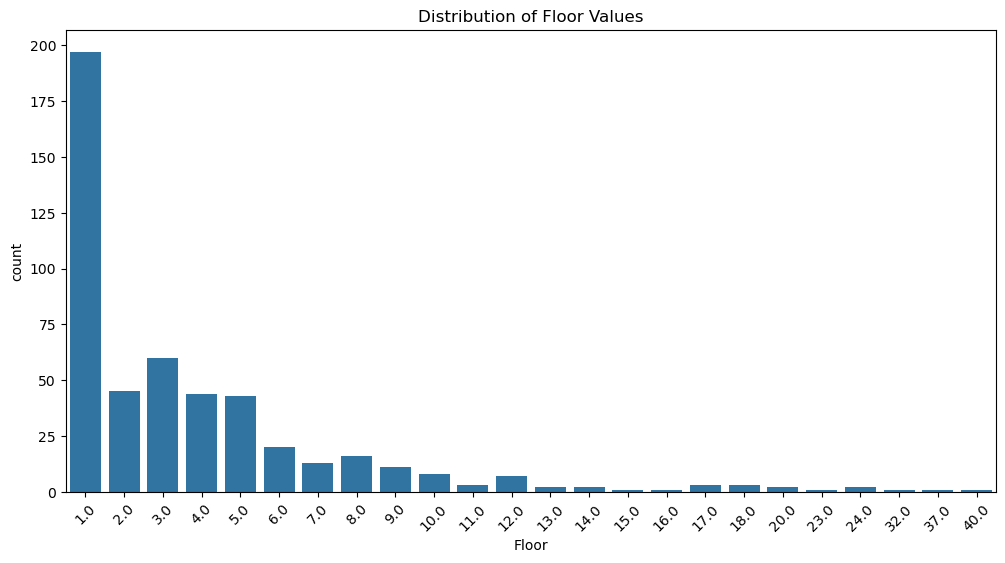

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(flats['Floor'].value_counts().sort_index())
plt.title('Distribution of Floor Values')
plt.xticks(rotation=45)
plt.show()

In [38]:
# Check flats with very high floors
flats[flats['Floor'] > 15][['Price(Cr)', 'Area(Marla)', 'Floor', 'Location', 'Bedroom(s)','Floor in Building']]

,Price(Cr),Area(Marla),Floor,Location,Bedroom(s),Floor in Building
283,3.90,3.0,37.0,F-8,1.0,37.0
421,2.94,7.3,24.0,DHA Defence,3.0,40.0
436,2.94,7.3,24.0,DHA Defence,3.0,40.0
716,1.06,2.8,17.0,DHA Defence,NaN,14.0
781,7.50,7.1,18.0,Blue Area,2.0,22.0
919,1.08,2.7,17.0,DHA Defence,1.0,40.0
1181,2.50,8.9,40.0,DHA Defence,2.0,40.0
1256,1.04,4.9,18.0,Top City 1,2.0,18.0
1372,3.35,8.0,20.0,G-11,2.0,25.0
1480,2.70,7.6,23.0,Gulberg,2.0,26.0


In [39]:
flats['Amenities: Main Features'].loc[1480]

'Built in year: 2025, Parking Spaces: 7, Lobby in Building, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor: 23, Floors in Building: 26, Elevators: 03, Service Elevators in Building, Other Main Features, Furnished'

In [40]:
# Caculating the difference between Floor and Floor in Building to check if there is any error
flats['Floor Diff'] = flats['Floor in Building'] - flats['Floor']

In [41]:
flats['Floor Diff'].value_counts().sort_index()

Floor Diff
-13.0     1
-10.0     1
-5.0      1
-4.0      3
-3.0      5
-2.0      1
-1.0      6
 0.0     79
 1.0     23
 2.0     45
 3.0     37
 4.0     37
 5.0     34
 6.0     35
 7.0     29
 8.0     40
 9.0     18
 10.0    11
 11.0     6
 12.0     4
 13.0     8
 14.0     4
 15.0     1
 16.0     3
 17.0     5
 18.0     3
 19.0     2
 20.0     2
 21.0     2
 23.0     1
 28.0     1
 29.0     3
 30.0     1
 31.0     4
Name: count, dtype: int64

In [42]:
flats[flats['Floor Diff'] < 0][['Floor','Floor in Building']]

,Floor,Floor in Building
98,5.0,2.0
154,2.0,1.0
214,2.0,1.0
367,5.0,1.0
716,17.0,14.0
738,2.0,1.0
740,3.0,1.0
821,6.0,2.0
822,5.0,4.0
1258,9.0,6.0


*Swapping the values of Floor and Floor in Building, where the Difference is negative. Because the error could be that the Agent made an error.*

In [43]:
# Swapping the values where the Floor Diff is negative
mask = flats['Floor Diff'] < 0
cols_to_swap = ['Floor','Floor in Building']

flats.loc[mask,cols_to_swap] = flats.loc[mask,cols_to_swap[::-1]].values

In [44]:
flats.drop(columns='Floor Diff',inplace =True)

*After researching, I came to know that there are few buildings where Floor > 15, but there are also some mistakes.<br>
So that is why I am not changing the column for now but I will use discretization on this column to minimize the effect of Outliers*

### Elevators

<Axes: xlabel='Elevators', ylabel='count'>

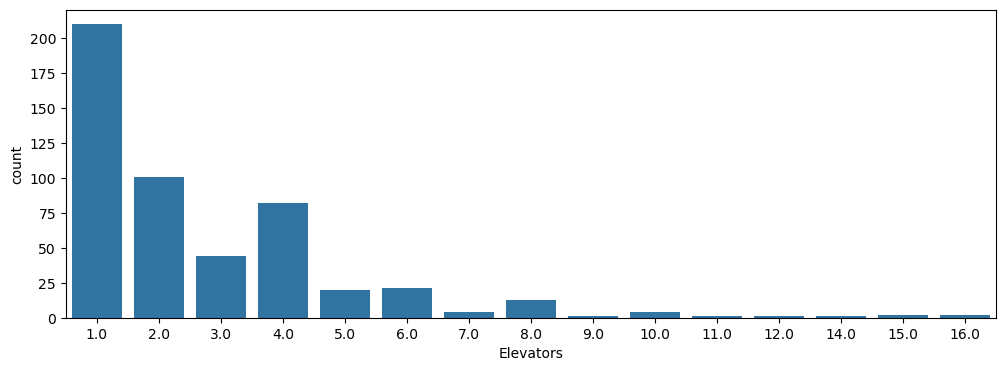

In [45]:
# Value count plot
plt.figure(figsize=(12,4))
sns.barplot(flats['Elevators'].value_counts())

In [46]:
flats['Amenities: Main Features'].loc[46]

'Built in year: 2, Parking Spaces, Lobby in Building, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor: 9, Floors in Building: 9, Other Main Features, Furnished'

In [47]:
flats['Amenities: Main Features'].str.contains('Floors in Building').sum()

np.int64(490)

In [48]:
flats.info()

<class 'pandas.DataFrame'>
Index: 721 entries, 16 to 2859
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type                                   721 non-null    str    
 1   Price(Cr)                              721 non-null    float64
 2   Bath(s)                                712 non-null    float64
 3   Area(Marla)                            721 non-null    float64
 4   Bedroom(s)                             704 non-null    float64
 5   Location                               721 non-null    str    
 6   Description                            721 non-null    str    
 7   Amenities: Main Features               681 non-null    str    
 8   Amenities: Rooms                       651 non-null    str    
 9   Amenities: Business and Communication  626 non-null    str    
 10  Amenities: Community Features          631 non-null    str    
 11  Amenities: Healthcar

### Kitchens

In [49]:
flats['Kitchens'].value_counts()

Kitchens
1.0    488
0.0     70
2.0     66
3.0      2
5.0      1
Name: count, dtype: int64

In [50]:
flats[flats['Kitchens']==0].iloc[1]['Amenities: Rooms']

'Bedrooms: 6, Bathrooms: 7, Servant Quarters, Drawing Room, Dining Room, Kitchens, Study Room, Prayer Room, Powder Room, Store Rooms, Steam Room, Lounge or Sitting Room, Laundry Room'

In [51]:
flats[~(flats['Communal/Shared Kitchen'].isnull())].iloc[2]

Type                                                                                  Flat
Price(Cr)                                                                              6.0
Bath(s)                                                                                7.0
Area(Marla)                                                                           22.0
Bedroom(s)                                                                             9.0
Location                                                                              H-13
Description                              Discover a one-of-a-kind investment in the hea...
Amenities: Main Features                 Built in year: 2025, Parking Spaces, Lobby in ...
Amenities: Rooms                         Bedrooms: 09, Bathrooms: 09, Servant Quarters,...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features            Community Lawn or Garden, Community Swimming P...

*Performing Multivariate Techniques to detect outliers for Kitchens, because there could be human error when entering the valeus for Kitchens*

### Parking Spaces

<Axes: xlabel='Parking Spaces', ylabel='count'>

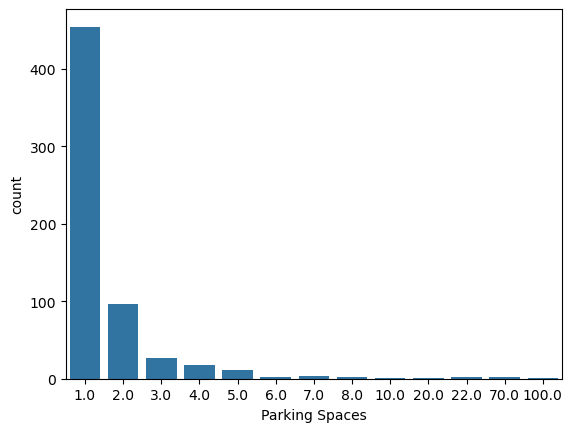

In [138]:
sns.barplot(flats['Parking Spaces'].value_counts())

In [141]:
# Capping the vaues till 3 for Parking Spaces
flats['Parking Spaces'] =  flats['Parking Spaces'].clip(lower=1,upper=3)

# Multivariate Approach
Now, we will use Multivariate Techiniques to detect Outliers.Following are the techniques:

- Isolation Forest
- Local Outlier Factor

In [ ]:
# Isolation Forest

In [76]:
# Choosing 'Area','Bedroom(s)','Bath(s)','Kitchens' 
cols_to_use = ['Bath(s)', 'Area(Marla)', 'Bedroom(s)','Kitchens']

data = flats[cols_to_use].copy()

In [77]:
# Filling the missing values

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

data = pd.DataFrame(imputer.fit_transform(data),columns=cols_to_use)
data.head()

,Bath(s),Area(Marla),Bedroom(s),Kitchens
0,2.0,6.1,2.0,1.0
1,2.0,4.5,2.0,1.0
2,2.0,3.9,2.0,1.0
3,2.0,3.8,2.0,1.0
4,1.0,3.2,1.0,0.0


In [78]:
data.isnull().sum()

Bath(s)        0
Area(Marla)    0
Bedroom(s)     0
Kitchens       0
dtype: int64

In [119]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=400,contamination=0.03)
clf.fit(data)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",400
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [120]:
y_pred = clf.predict(data)

In [121]:
is_outlier_forest = y_pred == -1

In [122]:
flats.loc[is_outlier_forest,cols_to_use]

,Bath(s),Area(Marla),Bedroom(s),Kitchens
97,7.0,22.0,9.0,5.0
154,5.0,11.7,3.0,0.0
241,6.0,4.1,5.0,2.0
424,4.0,19.1,4.0,0.0
496,6.0,19.3,4.0,2.0
723,6.0,20.0,4.0,1.0
737,1.0,2.1,1.0,3.0
799,5.0,12.0,4.0,2.0
920,5.0,4.2,4.0,1.0
1258,4.0,18.7,4.0,1.0


In [115]:
# Local Outlier Factor
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=25,contamination=0.03)

y_pred = lof.fit_predict(data)

In [116]:
is_outlier_lof = y_pred == -1

In [117]:
flats.loc[is_outlier_lof,cols_to_use]

,Bath(s),Area(Marla),Bedroom(s),Kitchens
500,1.0,2.9,2.0,1.0
570,3.0,4.0,2.0,1.0
650,3.0,3.7,3.0,1.0
667,1.0,2.8,1.0,2.0
716,1.0,2.8,NaN,NaN
740,1.0,2.8,1.0,0.0
754,1.0,2.8,1.0,2.0
924,2.0,3.6,3.0,1.0
1549,1.0,2.7,1.0,2.0
1551,1.0,4.0,NaN,NaN


In [123]:
flats.loc[is_outlier_forest,cols_to_use].index == flats.loc[is_outlier_lof,cols_to_use].index

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

*After looking at the Outliers detected by both LOF and Isolation Forest, it can be seen that the Outliers detected by LOF is more reliable because 2,3 Marla cannot have 3,4 Bathrooms and Bedrooms, while 20 Marla can have 4 Bathrooms and Bedrooms*

In [127]:
# Removing the Outliers detected by LOF
flats = flats.loc[~is_outlier_lof]

In [163]:
# Removing the Columns which are not usefull for predicting price
cols_to_remove = ['Type','SolarInstalled','WaterBore', 'CornerHouse', 'Security Staff',
       'Maintenance Staff','Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen', 'Storey Unit','Community Swimming Pool', 'Community Gym']

In [164]:
flats.drop(columns=cols_to_remove,inplace=True)

In [165]:
flats.info()

<class 'pandas.DataFrame'>
Index: 699 entries, 16 to 2859
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Price(Cr)                              699 non-null    float64
 1   Bath(s)                                690 non-null    float64
 2   Area(Marla)                            699 non-null    float64
 3   Bedroom(s)                             685 non-null    float64
 4   Location                               699 non-null    str    
 5   Description                            699 non-null    str    
 6   Amenities: Main Features               659 non-null    str    
 7   Amenities: Rooms                       631 non-null    str    
 8   Amenities: Business and Communication  606 non-null    str    
 9   Amenities: Community Features          610 non-null    str    
 10  Amenities: Healthcare Recreational     513 non-null    str    
 11  Amenities: Other Fac

In [167]:
flats.to_csv('flats_outlier_handled.csv')